## Multi-Layer Perceptron Neural Network

In [13]:
# import necessary libs
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random

## Example: Digit Recognition with Multi-layer Perceptron

In [ ]:
digits = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/data/digits.csv")

labels = digits['label']
digits = np.array(digits.drop('label', axis=1)).astype('float')
digits.shape, labels.shape

((42000, 784), (42000,))

There are 42,000 digit images and each has 784 pixels, which means we can reshape them into $28\times28$ images for displaying.

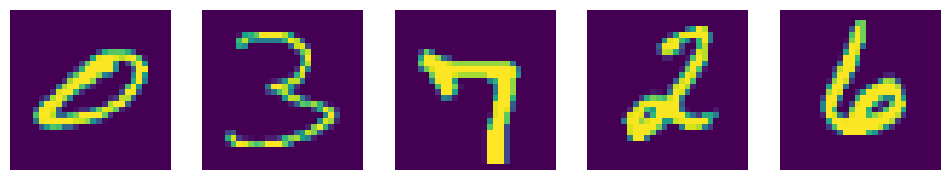

In [15]:
plt.figure(figsize=(12,4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(random.choice(digits).reshape(28,28))
    plt.axis("off")

Let's split the 42,000 images into train and test sets.

In [16]:
split = 0.7, 0.3

digits /= 255.0

split_ind = int(len(digits) * split[0])

X_train, X_test, y_train, y_test = digits[:split_ind], digits[split_ind:], labels[:split_ind], labels[split_ind:]
X_train.shape, X_test.shape

((29399, 784), (12601, 784))

With scikit-learn's **MLPClassifier**, we can utilize the GridSearch cross validation method to optimize the following parameters:

- **hidden_layer_sizes: _tuple, length = n_layers - 2, default=(100,)_**. The ith element represents the number of neurons in the ith hidden layer.

- **alpha: _float, default=0.0001_**. Strength of the L2 regularization term. The L2 regularization term is divided by the sample size when added to the loss.

- **max_iter: _int, default=200_**. Maximum number of iterations. The solver iterates until convergence (determined by ‘tol’) or this number of iterations. For stochastic solvers (‘sgd’, ‘adam’), note that this determines the number of epochs (how many times each data point will be used), not the number of gradient steps.

- **learning_rate_init: _float, default=0.001_**. The initial learning rate used. It controls the step-size in updating the weights. Only used when solver=’sgd’ or ‘adam’.

In [18]:
# fit the MLPClassifier first before tuning through parameter search
mlp = MLPClassifier()
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

print(f"MLPClassifier Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("=======================================")
print(classification_report(y_test, y_pred))

MLPClassifier Accuracy Score: 0.9719
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1263
           1       0.98      0.99      0.98      1410
           2       0.97      0.98      0.97      1226
           3       0.97      0.96      0.97      1317
           4       0.97      0.97      0.97      1184
           5       0.97      0.96      0.96      1135
           6       0.98      0.98      0.98      1227
           7       0.98      0.98      0.98      1332
           8       0.96      0.97      0.97      1235
           9       0.96      0.95      0.96      1272

    accuracy                           0.97     12601
   macro avg       0.97      0.97      0.97     12601
weighted avg       0.97      0.97      0.97     12601



## Hyperparameter Tuning using RandomizedSearchCV

In [21]:
parameters = {
    'hidden_layer_sizes' : [50, 100, 200],
    'alpha' : [0.001, 0.01, 0.1],
    'max_iter' : [200, 500, 800],
    'learning_rate_init' : [0.0001, 0.001, 0.01, 0.1]}

mlp_clf = MLPClassifier()

clf = RandomizedSearchCV(estimator=mlp_clf, param_distributions=parameters,
                         cv=5)

clf.fit(X_train[:3000], y_train[:3000])
print("The best parameters found are:")
print("==============================")
print(f"Best Parameters: {clf.best_params_}")

best_model = clf.best_estimator_

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


The best parameters found are:
Best Parameters: {'max_iter': 500, 'learning_rate_init': 0.01, 'hidden_layer_sizes': 200, 'alpha': 0.01}


Tuned MLPClassifier Acc Score: 0.937


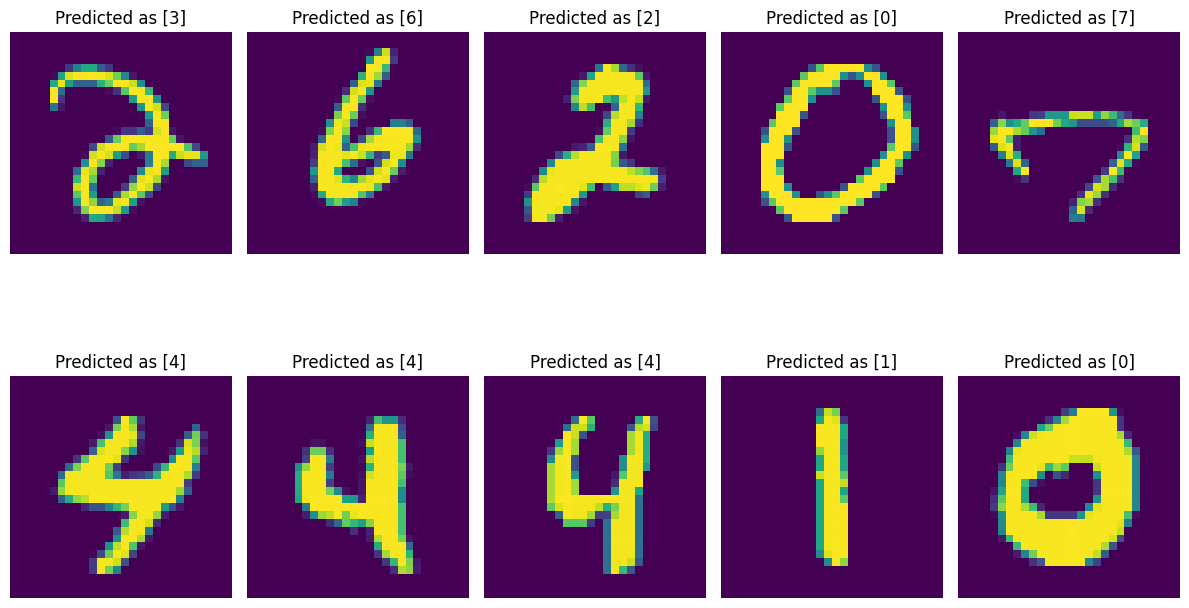

In [23]:
y_pred = best_model.predict(X_test)
print(f"Tuned MLPClassifier Acc Score: {accuracy_score(y_test, y_pred):.3f}")

plt.figure(figsize=(12,8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    sample = random.choice(X_test)
    plt.imshow(sample.reshape(28, 28))
    predict = best_model.predict(sample.reshape(1, -1))
    plt.title(f"Predicted as {predict}")
    plt.axis("off")


plt.tight_layout()